# Pertemuan 11: Clustering dengan K-Means
**Data Science Practicum - Diploma 3**

## Tujuan Pembelajaran

Setelah menyelesaikan pertemuan ini, mahasiswa diharapkan mampu:
1. Memahami konsep dasar Unsupervised Learning dan perbedaannya dengan Supervised Learning
2. Mengimplementasikan algoritma K-Means Clustering
3. Menentukan jumlah cluster optimal menggunakan Elbow Method dan Silhouette Score
4. Menganalisis dan menginterpretasi karakteristik setiap cluster
5. Mengaplikasikan clustering untuk customer segmentation

---

## Pengenalan Unsupervised Learning

### Apa itu Unsupervised Learning?

**Unsupervised Learning** adalah paradigma machine learning dimana model belajar dari data yang tidak memiliki label atau target variable. Berbeda dengan Supervised Learning yang bertujuan memprediksi output berdasarkan input, Unsupervised Learning fokus pada menemukan struktur tersembunyi atau pola dalam data.

### Perbandingan Supervised vs Unsupervised Learning

| Aspek | Supervised Learning | Unsupervised Learning |
|-------|-------------------|---------------------|
| Data | Memiliki label/target (X, y) | Tidak memiliki label (hanya X) |
| Tujuan | Prediksi output | Menemukan pola/struktur |
| Evaluasi | Menggunakan metrik akurasi | Menggunakan metrik seperti Silhouette Score |
| Contoh Algoritma | Linear Regression, Logistic Regression, Decision Tree | K-Means, DBSCAN, Hierarchical Clustering |
| Use Case | Prediksi harga rumah, klasifikasi email spam | Segmentasi pelanggan, deteksi anomali |

### Apa itu Clustering?

**Clustering** adalah teknik Unsupervised Learning yang bertujuan mengelompokkan data ke dalam beberapa grup (cluster) berdasarkan kesamaan karakteristik. Data dalam satu cluster memiliki karakteristik yang mirip, sedangkan data antar cluster berbeda.

**Aplikasi Clustering dalam Dunia Nyata:**
- **Customer Segmentation**: Mengelompokkan pelanggan berdasarkan perilaku pembelian untuk targeted marketing
- **Image Segmentation**: Memisahkan objek dalam gambar berdasarkan warna atau tekstur
- **Document Clustering**: Mengelompokkan artikel berita berdasarkan topik
- **Anomaly Detection**: Mendeteksi transaksi fraud atau aktivitas mencurigakan
- **Recommendation System**: Mengelompokkan produk atau user dengan preferensi serupa

---

## Algoritma K-Means

### Cara Kerja K-Means

K-Means adalah algoritma clustering yang paling populer dan sederhana. Algoritma ini bekerja dengan cara:

1. **Inisialisasi**: Tentukan jumlah cluster (K) dan pilih K titik centroid secara random
2. **Assignment**: Assign setiap data point ke centroid terdekat berdasarkan jarak Euclidean
3. **Update**: Hitung ulang posisi centroid sebagai rata-rata dari semua data point dalam cluster tersebut
4. **Iterasi**: Ulangi langkah 2-3 hingga centroid tidak berubah lagi (konvergen)

### Jarak Euclidean

K-Means menggunakan jarak Euclidean untuk mengukur kedekatan antar data point:

```
distance = √[(x₁ - x₂)² + (y₁ - y₂)²]
```

Semakin kecil jaraknya, semakin mirip karakteristik kedua data point tersebut.

### Kelebihan dan Kekurangan K-Means

**Kelebihan:**
- Sederhana dan mudah diimplementasikan
- Efisien untuk dataset besar
- Hasil konsisten jika centroid awal sama
- Cocok untuk cluster berbentuk bulat (spherical)

**Kekurangan:**
- Harus menentukan K terlebih dahulu
- Sensitif terhadap outlier
- Sensitif terhadap inisialisasi centroid awal
- Tidak cocok untuk cluster dengan bentuk kompleks
- Memerlukan standardisasi jika skala fitur berbeda

## 1. Import Libraries dan Load Dataset

### Dataset: Mall Customer Segmentation

Dataset ini berisi data pelanggan dari sebuah mall yang mencakup informasi demografis dan perilaku belanja. Dataset dapat diunduh dari Kaggle:

**Source**: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**Deskripsi Fitur:**
- **CustomerID**: ID unik untuk setiap pelanggan (1-200)
- **Gender**: Jenis kelamin pelanggan (Male/Female)
- **Age**: Usia pelanggan dalam tahun
- **Annual Income (k$)**: Pendapatan tahunan dalam ribuan dollar (15-137k)
- **Spending Score (1-100)**: Skor yang diberikan mall berdasarkan perilaku belanja dan pola pembelian pelanggan

Spending Score adalah metrik yang dikembangkan oleh mall untuk mengukur loyalitas dan potensi belanja pelanggan. Skor tinggi mengindikasikan pelanggan yang sering berbelanja dengan nilai transaksi besar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploratory Data Analysis

### Mengapa EDA Penting untuk Clustering?

Sebelum melakukan clustering, kita perlu memahami distribusi data dan hubungan antar fitur:
- **Distribusi**: Membantu mengidentifikasi outlier dan skewness
- **Korelasi**: Memahami fitur mana yang memiliki hubungan kuat
- **Scatter plots**: Melihat potensi pengelompokan secara visual

Pemahaman ini akan membantu kita dalam:
- Memilih fitur yang tepat untuk clustering
- Menentukan jumlah cluster yang masuk akal
- Menginterpretasi hasil clustering dengan lebih baik

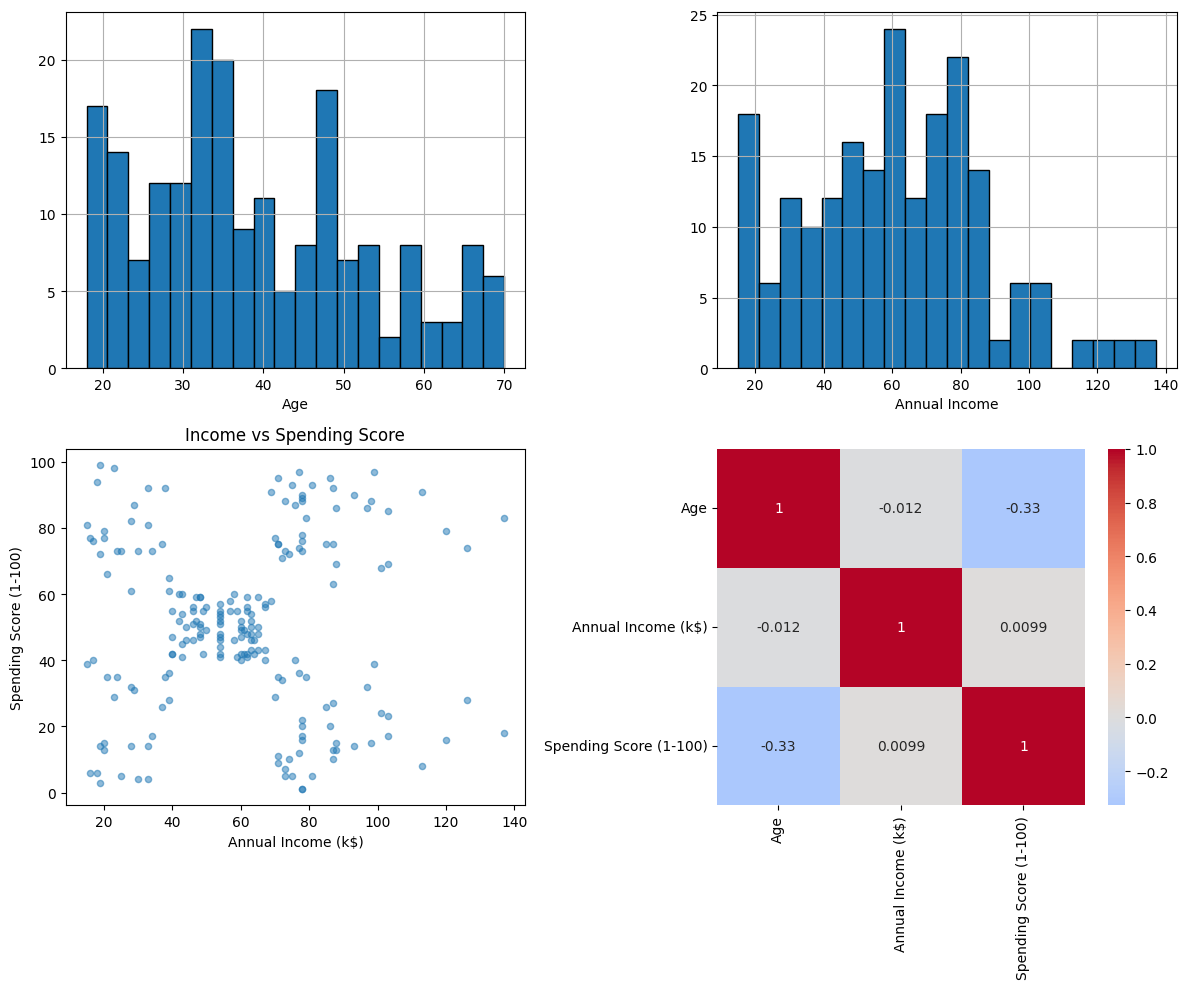

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df['Age'].hist(bins=20, ax=axes[0,0], edgecolor='black')
axes[0,0].set_xlabel('Age')

df['Annual Income (k$)'].hist(bins=20, ax=axes[0,1], edgecolor='black')
axes[0,1].set_xlabel('Annual Income')

df.plot.scatter(x='Annual Income (k$)', y='Spending Score (1-100)', ax=axes[1,0], alpha=0.5)
axes[1,0].set_title('Income vs Spending Score')

corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,1], center=0)

plt.tight_layout()
plt.show()

### Insight dari EDA:

Dari scatter plot **Income vs Spending Score**, kita dapat melihat adanya pola pengelompokan yang jelas:
- Pelanggan dengan income tinggi dan spending tinggi (high value customers)
- Pelanggan dengan income tinggi tapi spending rendah (potential customers)
- Pelanggan dengan income rendah tapi spending tinggi (impulsive buyers)
- Pelanggan dengan income rendah dan spending rendah (budget conscious)

Pola ini mengindikasikan bahwa clustering akan memberikan segmentasi yang bermakna.

### Analisis Korelasi:

Correlation matrix menunjukkan bahwa:
- Tidak ada korelasi kuat antar fitur (semua nilai mendekati 0)
- Income dan Spending Score independen, artinya income tinggi tidak selalu berarti spending tinggi
- Age juga tidak berkorelasi dengan income atau spending

Ini adalah kondisi yang baik untuk clustering karena setiap fitur memberikan informasi unik.

## 3. Data Preparation dan Standardisasi

### Pentingnya Standardisasi dalam K-Means

**Mengapa perlu standardisasi?**

K-Means menggunakan jarak Euclidean untuk menghitung kedekatan antar data point. Jika fitur memiliki skala yang berbeda, fitur dengan nilai besar akan mendominasi perhitungan jarak.

**Contoh:**
- Income range: 15-137 (range = 122)
- Spending Score range: 1-100 (range = 99)
- Age range: 18-70 (range = 52)

Tanpa standardisasi, Income akan memiliki pengaruh lebih besar dalam perhitungan jarak dibanding Age.

**StandardScaler** mengubah data agar memiliki:
- Mean (rata-rata) = 0
- Standard Deviation = 1

Formula: `z = (x - μ) / σ`

Kita memilih Income dan Spending Score karena scatter plot menunjukkan pola pengelompokan yang jelas pada kedua fitur ini.

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Menentukan K Optimal dengan Elbow Method

### Elbow Method

**Elbow Method** adalah teknik untuk menentukan jumlah cluster optimal dengan cara:
1. Menjalankan K-Means untuk berbagai nilai K (misal: 2-10)
2. Menghitung **Inertia** (WCSS - Within-Cluster Sum of Squares) untuk setiap K
3. Plot grafik K vs Inertia
4. Pilih K di titik "siku" kurva (elbow point)

**Apa itu Inertia?**

Inertia mengukur seberapa kompak cluster yang terbentuk. Formula:

```
Inertia = Σ (jarak dari setiap point ke centroid cluster-nya)²
```

- Inertia kecil = cluster kompak (baik)
- Inertia besar = cluster menyebar (kurang baik)

**Mengapa tidak memilih K terbesar?**

Semakin besar K, semakin kecil inertia. Namun, terlalu banyak cluster akan membuat segmentasi tidak praktis. Elbow point adalah titik dimana penambahan K tidak lagi memberikan penurunan inertia yang signifikan.

### Silhouette Score

**Silhouette Score** mengukur seberapa baik sebuah data point cocok dengan cluster-nya dibanding cluster lain.

- Range: -1 sampai 1
- Score mendekati 1: data point sangat cocok dengan cluster-nya
- Score mendekati 0: data point berada di boundary antar cluster
- Score negatif: data point mungkin salah cluster

**Interpretasi:**
- 0.71 - 1.0: Struktur cluster sangat kuat
- 0.51 - 0.70: Struktur cluster cukup baik
- 0.26 - 0.50: Struktur cluster lemah
- < 0.26: Tidak ada struktur cluster yang jelas

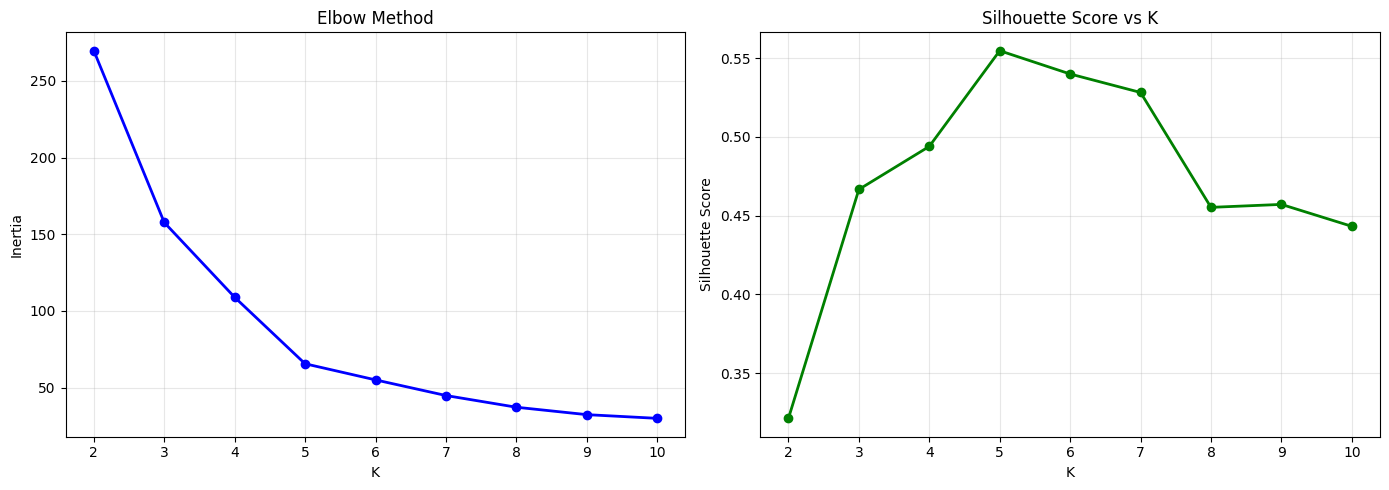

In [4]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi Hasil:

Dari kedua grafik di atas:
- **Elbow Method**: Terlihat "siku" di K=5, dimana penurunan inertia mulai melambat
- **Silhouette Score**: K=5 memberikan score yang tinggi dan stabil

Kesimpulan: **K optimal = 5 cluster**

Kelima cluster ini akan merepresentasikan segmen pelanggan yang berbeda berdasarkan income dan spending pattern.

## 5. Build K-Means Model dan Visualisasi

Setelah menentukan K=5, kita akan:
1. Membuat model K-Means dengan 5 cluster
2. Melakukan fitting pada data yang sudah di-standardisasi
3. Memprediksi label cluster untuk setiap pelanggan

Parameter penting:
- `n_clusters=5`: jumlah cluster yang ingin dibentuk
- `random_state=42`: untuk reproducibility
- `n_init=10`: jumlah kali algoritma dijalankan dengan centroid awal berbeda, ambil hasil terbaik

Visualisasi clustering membantu kita:
- Memahami posisi relatif setiap cluster
- Melihat seberapa terpisah antar cluster
- Mengidentifikasi overlap atau ambiguitas
- Memvalidasi hasil clustering secara visual

**Centroid** (tanda X hitam) adalah titik pusat dari setiap cluster, merepresentasikan karakteristik rata-rata dari cluster tersebut.

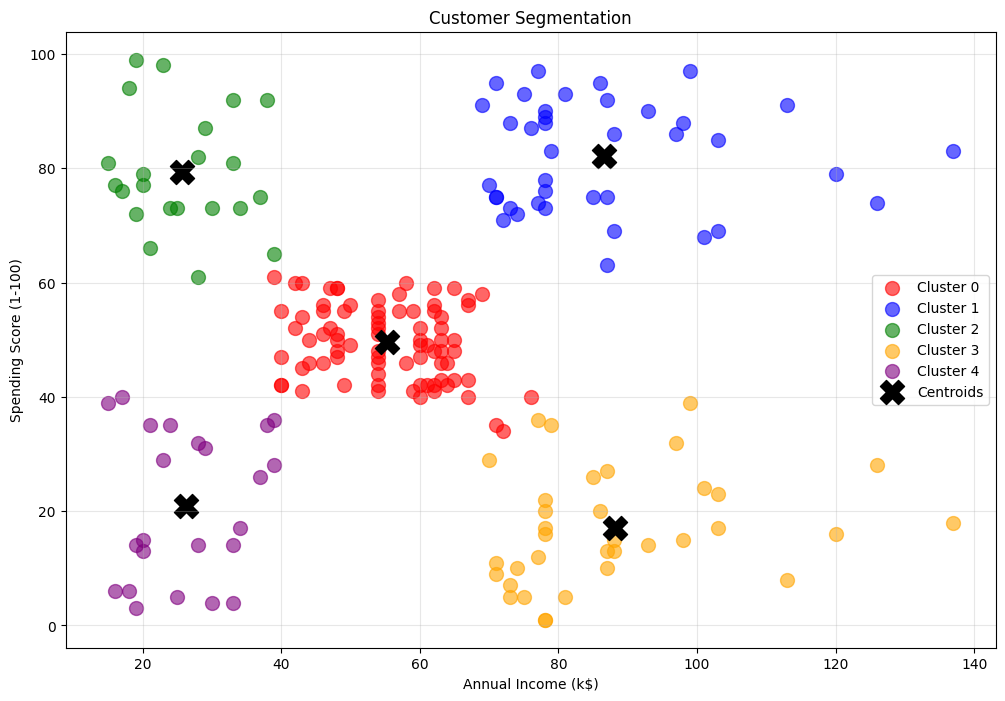

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'], 
                cluster_data['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i}', alpha=0.6, s=100)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=300, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretasi Visual Clustering:

Dari visualisasi di atas, kita dapat mengidentifikasi 5 segmen pelanggan yang jelas:

**Cluster 0 (Merah)**: Income rendah, Spending rendah
- Karakteristik: Budget-conscious customers

**Cluster 1 (Biru)**: Income tinggi, Spending rendah  
- Karakteristik: Wealthy but careful spenders

**Cluster 2 (Hijau)**: Income sedang, Spending sedang
- Karakteristik: Average customers

**Cluster 3 (Orange)**: Income tinggi, Spending tinggi
- Karakteristik: High-value customers

**Cluster 4 (Ungu)**: Income rendah, Spending tinggi
- Karakteristik: Impulsive buyers

Setiap cluster terpisah dengan jelas, mengkonfirmasi bahwa clustering berhasil mengidentifikasi segmen yang berbeda.

## 6. Analisis Karakteristik Cluster

Setelah clustering, langkah penting adalah **profiling** - menganalisis karakteristik setiap cluster untuk memahami siapa mereka dan bagaimana perilaku mereka.

Profiling membantu dalam:
- **Business Understanding**: Memahami siapa target market untuk setiap strategi
- **Decision Making**: Menentukan produk, harga, dan promosi yang sesuai
- **Resource Allocation**: Mengalokasikan budget marketing secara efektif
- **Personalization**: Memberikan pengalaman yang disesuaikan untuk setiap segmen

In [6]:
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).round(2)
cluster_profile.columns = ['Avg_Age', 'Avg_Income', 'Avg_Spending', 'Count']
cluster_profile

,Avg_Age,Avg_Income,Avg_Spending,Count
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


### Detail Profil Setiap Cluster:

**Cluster 0**: 
- Average Age, Low Income, Low Spending
- Segmen: "Budget Shoppers" - Pelanggan yang hati-hati dalam berbelanja
- Rekomendasi: Tawarkan produk value for money, discount programs

**Cluster 1**: 
- Average Age, High Income, Low Spending
- Segmen: "Potential Customers" - Memiliki daya beli tinggi tapi jarang belanja
- Rekomendasi: Targeted campaigns, loyalty programs, personalized offers

**Cluster 2**: 
- Average Age, Medium Income, Medium Spending
- Segmen: "Average Customers" - Backbone dari mall
- Rekomendasi: Maintain engagement dengan seasonal promotions

**Cluster 3**: 
- Younger Age, High Income, High Spending
- Segmen: "Premium Customers" - Most valuable segment
- Rekomendasi: VIP treatment, exclusive products, premium services

**Cluster 4**: 
- Younger Age, Low Income, High Spending
- Segmen: "Impulsive Buyers" - Belanja di luar kemampuan finansial
- Rekomendasi: Installment plans, flash sales, emotional marketing

## 7. Visualisasi Profil dan Distribusi

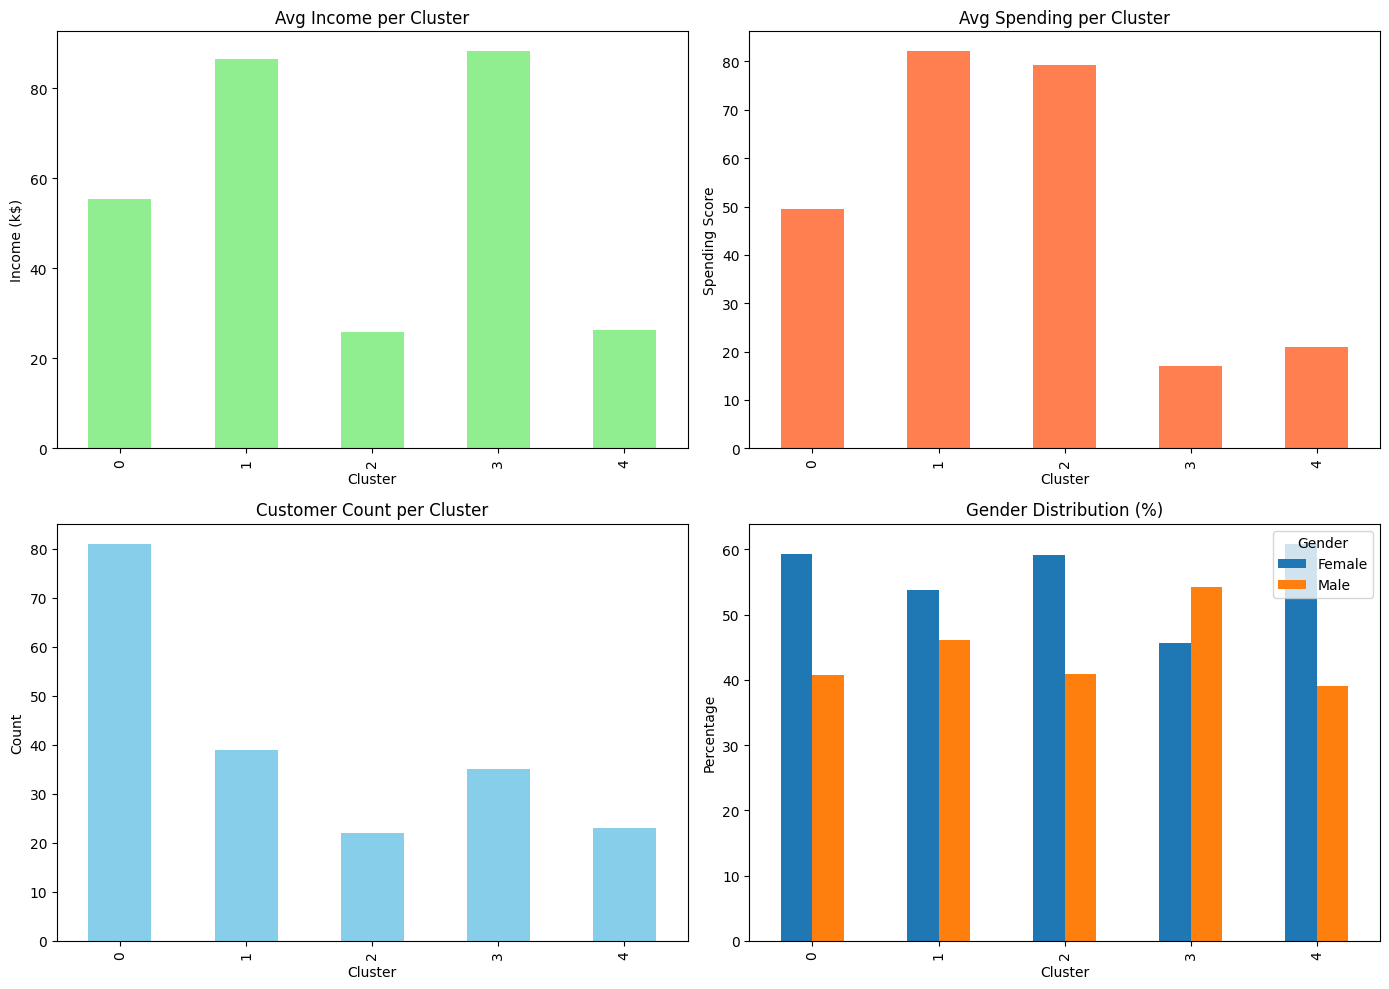

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cluster_profile['Avg_Income'].plot(kind='bar', ax=axes[0,0], color='lightgreen')
axes[0,0].set_title('Avg Income per Cluster')
axes[0,0].set_ylabel('Income (k$)')

cluster_profile['Avg_Spending'].plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Avg Spending per Cluster')
axes[0,1].set_ylabel('Spending Score')

cluster_profile['Count'].plot(kind='bar', ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Customer Count per Cluster')
axes[1,0].set_ylabel('Count')

gender_dist = pd.crosstab(df['Cluster'], df['Gender'], normalize='index') * 100
gender_dist.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Gender Distribution (%)')
axes[1,1].set_ylabel('Percentage')

for ax in axes.flat:
    ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

Visualisasi di atas memperjelas perbedaan karakteristik antar cluster:
- Cluster 1 dan 3 memiliki income tertinggi
- Cluster 3 dan 4 memiliki spending score tertinggi
- Age relatif konsisten di semua cluster
- Distribusi gender memberikan insight tambahan untuk marketing strategy

## 8. Kesimpulan dan Rekomendasi

### Ringkasan Pembelajaran

Dalam pertemuan ini, kita telah berhasil:

1. **Memahami Unsupervised Learning**: Perbedaan dengan Supervised Learning dan aplikasinya
2. **Implementasi K-Means**: Dari data preparation hingga interpretasi hasil
3. **Menentukan K Optimal**: Menggunakan Elbow Method dan Silhouette Score
4. **Customer Segmentation**: Mengidentifikasi 5 segmen pelanggan dengan karakteristik berbeda
5. **Business Profiling**: Menganalisis karakteristik dan memberikan rekomendasi untuk setiap segmen

### Key Takeaways

**Teknis:**
- K-Means efektif untuk data dengan pola pengelompokan yang jelas
- Standardisasi sangat penting untuk hasil yang akurat
- Elbow Method dan Silhouette Score membantu menentukan K optimal
- Visualisasi adalah kunci untuk interpretasi yang baik

**Business:**
- Tidak semua pelanggan sama - segmentasi membantu personalisasi
- High-value customers (Cluster 3) harus mendapat perhatian khusus
- Potential customers (Cluster 1) adalah opportunity untuk growth
- Resource allocation harus disesuaikan dengan nilai dan potensi setiap segmen

### Strategi Marketing per Cluster

**Cluster 0 - Budget Shoppers**: Value for Money strategy, regular discounts, budget-friendly items

**Cluster 1 - Potential Customers**: Conversion & Engagement, personalized recommendations, loyalty rewards

**Cluster 2 - Average Customers**: Retention & Satisfaction, seasonal promotions, membership programs

**Cluster 3 - Premium Customers**: VIP Treatment, exclusive events, luxury brands, premium services

**Cluster 4 - Impulsive Buyers**: Facilitate & Protect, installment plans, flash sales, FOMO campaigns

### Limitasi dan Best Practices

**Limitasi K-Means:**
- Mengasumsikan cluster berbentuk bulat
- Sensitif terhadap outlier
- Harus menentukan K sebelumnya

**Best Practices:**
- Selalu lakukan EDA sebelum clustering
- Coba beberapa nilai K dan bandingkan hasilnya
- Validasi hasil dengan domain knowledge
- Update cluster secara berkala dengan data baru

---

## Homework: Clustering Titanic Passengers

**Objektif:** Melakukan clustering pada penumpang Titanic untuk mengidentifikasi pola karakteristik yang mempengaruhi tingkat survival.

**Steps:**

1. **Data Loading**: Load dataset Titanic dari Kaggle, explore dengan info() dan describe()

2. **Data Preparation**: Pilih fitur Age, Fare, SibSp, Parch. Handle missing values (Age dengan median, drop missing Fare)

3. **Standardization**: Gunakan StandardScaler untuk semua fitur

4. **Determine K**: Gunakan Elbow Method dan Silhouette Score untuk K=2-10

5. **Build Model**: Train K-Means dengan K optimal

6. **Visualization**: Buat scatter plots (Fare vs Age, PCA 2D) dan bar charts

7. **Cluster Profiling**: Hitung average Age, Fare, survival rate, gender & Pclass distribution per cluster

8. **Analysis**: Interpretasi - cluster mana survival rate tertinggi? Apa karakteristiknya? Business insights apa yang bisa diambil?

**Deliverables:**
- Jupyter Notebook dengan kode dan markdown lengkap
- Minimal 6 visualisasi
- Tabel profiling cluster
- Kesimpulan dengan business insights

**Deadline:** Sebelum UAS (Week 12)